In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# PART A: Image Classification using Convolutional Neural Networks

## Section 1: Library Imports

In [4]:
import os
import random
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD
from sklearn.utils.class_weight import compute_class_weight
import time

In [5]:
SEED_VAL = 42
tf.random.set_seed(SEED_VAL)
np.random.seed(SEED_VAL)
random.seed(SEED_VAL)

## Section 2: Dataset Paths

In [6]:
TRAIN_PATH = "/content/drive/MyDrive/Insect Classification/train"
TEST_PATH  = "/content/drive/MyDrive/Insect Classification/test"

## Section 3: Data Understanding & Visualization


### Insect Dataset
This dataset represents an insect classification dataset used for
image-based pest recognition. The dataset contains images of different
insect categories commonly found in agricultural environments.
The goal of the dataset is to train a deep learning model capable of
automatically classifying insect species from images.

### Total Images

In [7]:
category_counts = {}

for category in os.listdir(TRAIN_PATH):
    category_path = os.path.join(TRAIN_PATH, category)

    if os.path.isdir(category_path):
        image_count = len([
            file for file in os.listdir(category_path)
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        category_counts[category] = image_count

# Total images
total_images = sum(category_counts.values())

print(f"Total Images in Dataset: {total_images}")

Total Images in Dataset: 2090


### Classes

In [8]:
all_categories = sorted(os.listdir(TRAIN_PATH))
if not all_categories:
    print("Warning: No class subdirectories found in the training folder!")
else:
    print(f"Total categories detected: {len(all_categories)}")
    print(f"Category list: {all_categories}")

Total categories detected: 9
Category list: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


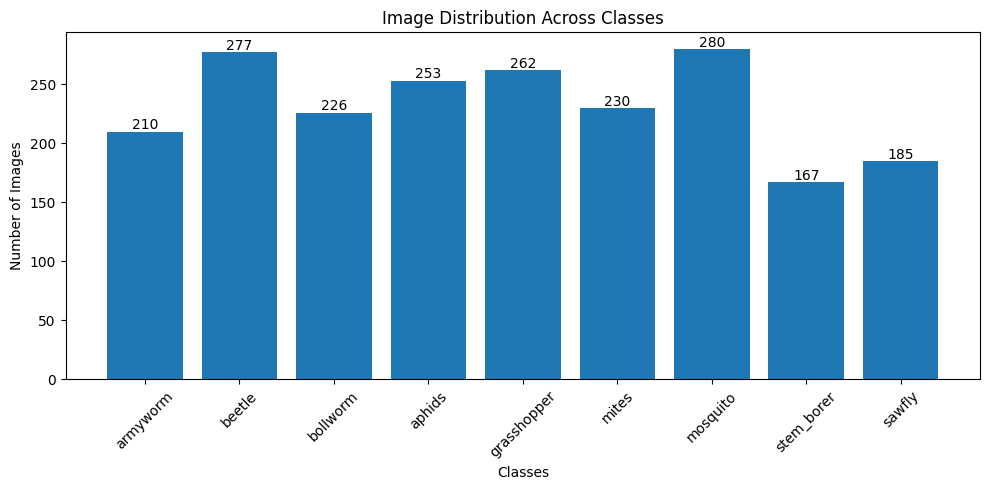

In [9]:
# Bar chart
plt.figure(figsize=(10, 5))

bars = plt.bar(
    category_counts.keys(),
    category_counts.values()
)

plt.title("Image Distribution Across Classes")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(height),
        ha='center'
    )

plt.tight_layout()
plt.show()

### Checking Corrupted Images.

In [10]:
bad_files = []
for category in all_categories:
    folder = os.path.join(TRAIN_PATH, category)
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            bad_files.append(fpath)
            os.remove(fpath)
            print(f"Deleted corrupted file: {fpath}")

if not bad_files:
    print("All images passed integrity check — no corrupted files found.")

All images passed integrity check — no corrupted files found.


### Class Count Balance

In [11]:
category_counts = {}
for cat in all_categories:
    cat_path = os.path.join(TRAIN_PATH, cat)
    if os.path.isdir(cat_path):
        valid_imgs = [
            f for f in os.listdir(cat_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        category_counts[cat] = len(valid_imgs)

print("\nImage Count Per Category")
print("=" * 42)
print(f"{'Category':<22} {'Image Count':>15}")
print("=" * 42)
for cat, cnt in category_counts.items():
    print(f"{cat:<22} {cnt:>15}")
print("=" * 42)


Image Count Per Category
Category                   Image Count
aphids                             253
armyworm                           210
beetle                             277
bollworm                           226
grasshopper                        262
mites                              230
mosquito                           280
sawfly                             185
stem_borer                         167


### Visualize One Sample Per Category

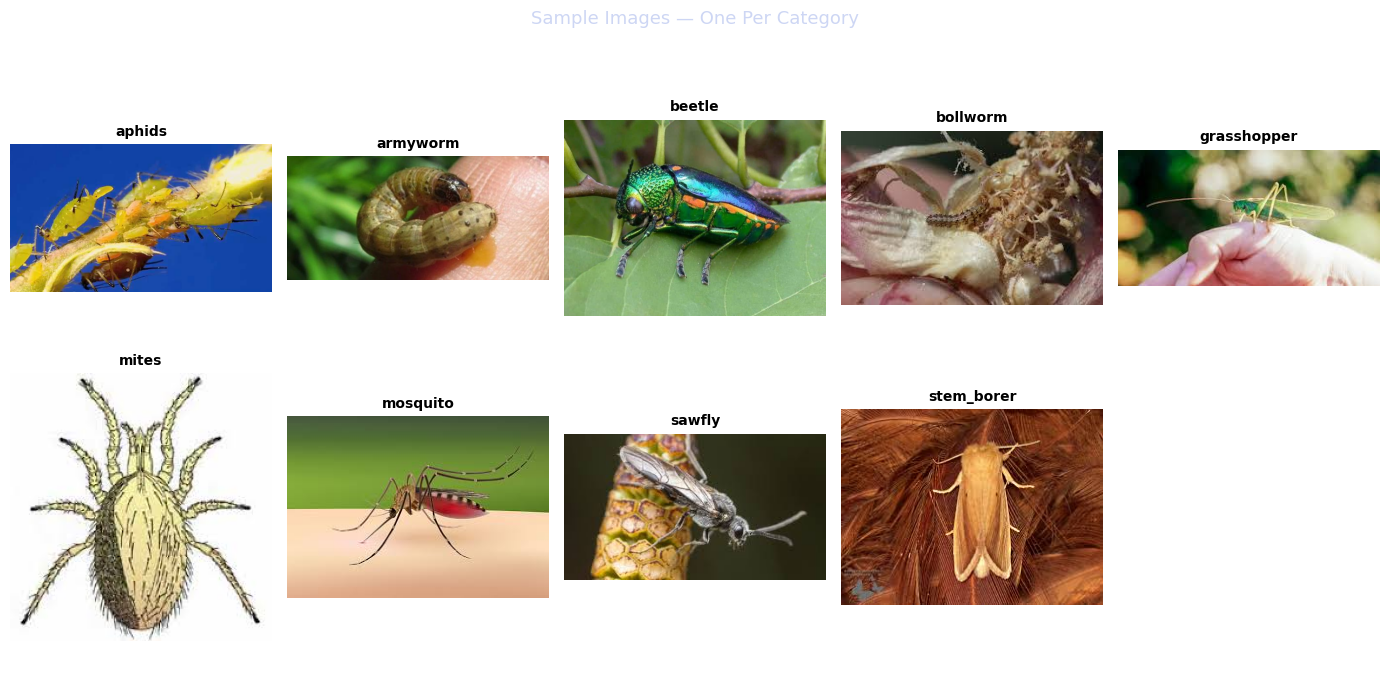

In [12]:
sample_paths  = []
sample_labels = []

for cat in all_categories:
    cat_folder = os.path.join(TRAIN_PATH, cat)
    if os.path.isdir(cat_folder):
        imgs = [
            f for f in os.listdir(cat_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        if imgs:
            chosen = os.path.join(cat_folder, random.choice(imgs))
            sample_paths.append(chosen)
            sample_labels.append(cat)

n_cats  = len(sample_paths)
n_cols  = (n_cats + 1) // 2
n_rows  = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7))

for idx, ax in enumerate(axes.flat):
    if idx < n_cats:
        pic = mpimg.imread(sample_paths[idx])
        ax.imshow(pic)
        ax.set_title(
            sample_labels[idx],
            fontsize=10,
            fontweight='bold'
        )
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("Sample Images — One Per Category", color='#cdd6f4', fontsize=13)
plt.tight_layout()
plt.show()

## Section 4: Data Preprocessing & Augmentation

## Dataset Splitting Strategy

The dataset was divided into training and validation sets
using an 80:20 split.

- 80% of the images are used for training
- 20% of the images are used for validation

The training dataset is used to learn patterns from the images,
while the validation dataset is used to evaluate model performance
during training and monitor overfitting.

A fixed random seed (SEED_VAL) is used to ensure reproducibility
of the dataset split.

The test dataset is loaded separately from the test directory
and is not used during training.

## Justification of the Split
An 80:20 split is commonly used in deep learning because it provides:

1. Sufficient training data for the model to learn useful patterns.
2. Enough validation data to evaluate generalization performance.
3. A balanced trade-off between training efficiency and model evaluation.

This split is suitable for medium-sized datasets and helps reduce
the risk of overfitting while maintaining reliable validation results.

## Image Size Selection
Initially, images were resized to 150 × 150 pixels for efficient experimentation and reduced computational cost. Later, the image dimension was changed to 224 × 224 pixels to support transfer learning models. This preserves more visual details and improves compatibility with pretrained convolutional neural network architectures.

In [13]:
IMG_DIM = 150
BATCH_SZ = 32

In [14]:
training_ds = keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED_VAL,
    image_size=(IMG_DIM, IMG_DIM),
    batch_size=BATCH_SZ
)

validation_ds = keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED_VAL,
    image_size=(IMG_DIM, IMG_DIM),
    batch_size=BATCH_SZ
)

evaluation_ds = keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_DIM, IMG_DIM),
    batch_size=BATCH_SZ,
    shuffle=False
)

Found 2090 files belonging to 9 classes.
Using 1672 files for training.
Found 2090 files belonging to 9 classes.
Using 418 files for validation.
Found 384 files belonging to 9 classes.


## Data Augmentation Pipeline
This data augmentation pipeline was used to artificially increase
dataset diversity and improve the model's ability to generalize
to unseen data.

The following augmentation techniques were applied:

1. Random Horizontal Flip
   - Randomly flips images horizontally.

2. Random Rotation
   - Randomly rotates images by a small angle.

3. Random Zoom
   - Randomly zooms into images.

4. Random Contrast Adjustment
   - Randomly changes image contrast to simulate different
     lighting conditions.

In [15]:
# Augmentation pipeline
augment_pipeline = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
]

Class Weights

In [16]:
y_train = []
for _, labels in training_ds:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights: ", class_weights)

Class Weights:  {0: np.float64(0.8931623931623932), 1: np.float64(1.0320987654320988), 2: np.float64(0.8293650793650794), 3: np.float64(0.998805256869773), 4: np.float64(0.8931623931623932), 5: np.float64(1.0096618357487923), 6: np.float64(0.8444444444444444), 7: np.float64(1.4181509754028838), 8: np.float64(1.4181509754028838)}


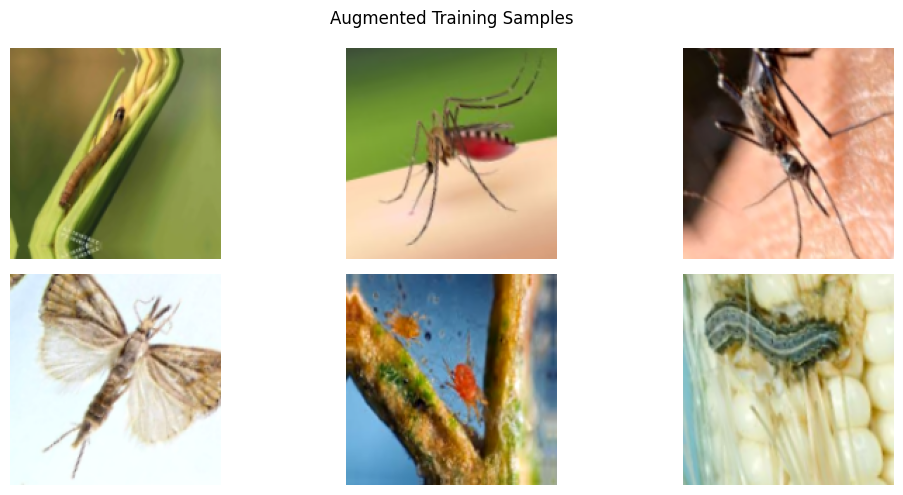

In [17]:
for img_batch, lbl_batch in training_ds.take(1):
    fig, axes = plt.subplots(2, 3, figsize=(11, 5))
    for i, ax in enumerate(axes.flat):
        augmented_img = img_batch[i]
        for aug_layer in augment_pipeline:
            augmented_img = aug_layer(augmented_img)
        ax.imshow(augmented_img.numpy().astype("uint8"))
        ax.axis("off")
    plt.suptitle("Augmented Training Samples", fontsize=12)
    plt.tight_layout()
    plt.show()


## Pixel Normalization
   - Pixel values were normalized using rescaling.
   - Original pixel values range from 0 to 255.
   - After normalization, pixel values are scaled to the range [0, 1].

   Formula Used:
       normalized_pixel = pixel / 255

In [18]:
pixel_normalizer = layers.Rescaling(1.0 / 255)

## Utility Functions

In [19]:
import matplotlib.pyplot as plt

def plot_training_curves(log, title_prefix="Model"):
    """
    Plots accuracy and loss curves for a training history object.
    Simple clean version (no custom styling).
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    epochs_range = range(1, len(log.history['accuracy']) + 1)

    # Accuracy plot
    ax1.plot(epochs_range, log.history['accuracy'], label='Training Accuracy', marker='o')
    ax1.plot(epochs_range, log.history['val_accuracy'], label='Validation Accuracy', marker='s')
    ax1.set_title(f"{title_prefix} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2.plot(epochs_range, log.history['loss'], label='Training Loss', marker='o')
    ax2.plot(epochs_range, log.history['val_loss'], label='Validation Loss', marker='s')
    ax2.set_title(f"{title_prefix} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [20]:
def plot_sample_predictions(model, dataset, class_names, num_images=9, grid_size=(3, 3), figsize=(10, 6)):
  """
    Renders sample predictions made by the model.
    """
  plt.figure(figsize=figsize)

  for images, labels in dataset.take(1):
      preds = model.predict(images[:num_images])

      for i in range(num_images):
          ax = plt.subplot(grid_size[0], grid_size[1], i + 1)

          plt.imshow(images[i].numpy().astype("uint8"))

          pred_label = class_names[np.argmax(preds[i])]
          true_label = class_names[labels[i].numpy()]

          color = "green" if pred_label == true_label else "red"

          plt.title(
              f"P: {pred_label}\nT: {true_label}",
              color=color,
              fontsize=8
          )
          plt.axis("off")

  plt.tight_layout()
  plt.show()

In [21]:
def plot_confusion_matrix(y_true, y_pred, class_labels, title="Confusion Matrix", cmap_name="Blues"):
    """
    Renders a simple confusion matrix heatmap.
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap_name,
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [22]:
def run_evaluation(model, dataset, label="Model"):
    """
    Generates predictions and prints a classification report.
    Returns y_true and y_pred arrays.
    """
    ground_truth = []
    for _, lbls in dataset:
        ground_truth.extend(lbls.numpy())
    ground_truth = np.array(ground_truth)

    raw_preds   = model.predict(dataset)
    predictions = np.argmax(raw_preds, axis=1)
    cat_names   = dataset.class_names

    print(f"\n{'='*50}")
    print(f"  Classification Report — {label}")
    print(f"{'='*50}")
    print(classification_report(ground_truth, predictions, target_names=cat_names))
    return ground_truth, predictions


## Section 5: Baseline CNN Model

In [23]:
NUM_CLASSES = len(training_ds.class_names)

def build_baseline_cnn(num_cls, aug_layers, normalizer):
    """
    Constructs a simple 3-block CNN classifier with augmentation baked in.
    """
    mdl = keras.Sequential([
        layers.Input(shape=(IMG_DIM, IMG_DIM, 3)),
        *aug_layers,
        normalizer,
        # Block 1
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(),
        # Block 2
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(),
        # Block 3
        layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(),
        # Fully connected head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(32,  activation='relu'),
        layers.Dense(num_cls, activation='softmax'),
    ])
    return mdl

baseline_cnn = build_baseline_cnn(NUM_CLASSES, augment_pipeline, pixel_normalizer)

In [24]:
baseline_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
baseline_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 150, 150, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,838,985 (18.46 MB)

 Trainable params: 4,838,985 (18.46 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Callbacks
stop_early   = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr    = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [26]:
baseline_start_time = time.time()

baseline_log = baseline_cnn.fit(
    training_ds,
    validation_data=validation_ds,
    epochs=40,
    callbacks=[stop_early, reduce_lr],
    class_weight=class_weights
)

baseline_end_time = time.time()
print(f"Training Time: {baseline_end_time - baseline_start_time} seconds")

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.1501 - loss: 2.1736 - val_accuracy: 0.1699 - val_loss: 2.1090 - learning_rate: 0.0010
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.2715 - loss: 2.0196 - val_accuracy: 0.2823 - val_loss: 1.8714 - learning_rate: 0.0010
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.3397 - loss: 1.8489 - val_accuracy: 0.2656 - val_loss: 2.0238 - learning_rate: 0.0010
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - accuracy: 0.4097 - loss: 1.6922 - val_accuracy: 0.4139 - val_loss: 1.6298 - learning_rate: 0.0010
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - accuracy: 0.4689 - loss: 1.5259 - val_accuracy: 0.4761 - val_loss: 1.6054 - learning_rate: 0.0010
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.5197 - loss: 1.4097 - val_accuracy: 0.5383 - val_loss: 1.3245 - learning_rate: 0.0010
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step - accuracy: 0.6041 - loss: 1.1696 

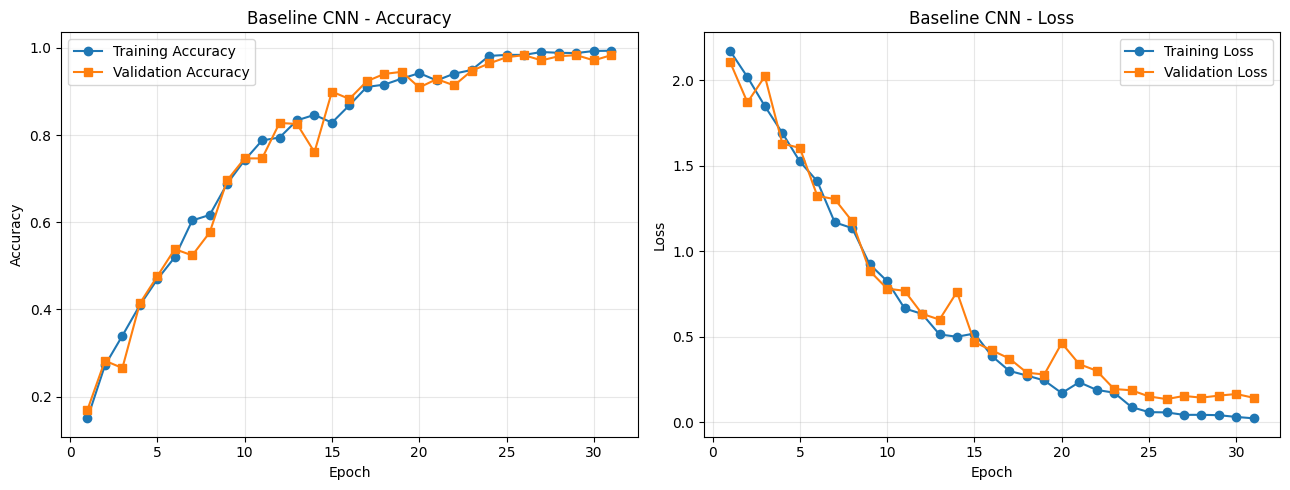

In [27]:
plot_training_curves(baseline_log, title_prefix="Baseline CNN")

In [28]:

baseline_true, baseline_pred = run_evaluation(baseline_cnn, evaluation_ds, "Baseline CNN")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step

  Classification Report — Baseline CNN
              precision    recall  f1-score   support

      aphids       0.90      1.00      0.95        44
    armyworm       1.00      0.91      0.95        43
      beetle       0.92      0.98      0.95        50
    bollworm       0.92      1.00      0.96        36
 grasshopper       0.98      0.96      0.97        46
       mites       0.97      0.90      0.94        42
    mosquito       0.98      1.00      0.99        50
      sawfly       0.97      0.89      0.93        37
  stem_borer       0.97      0.94      0.96        36

    accuracy                           0.96       384
   macro avg       0.96      0.95      0.95       384
weighted avg       0.96      0.96      0.96       384



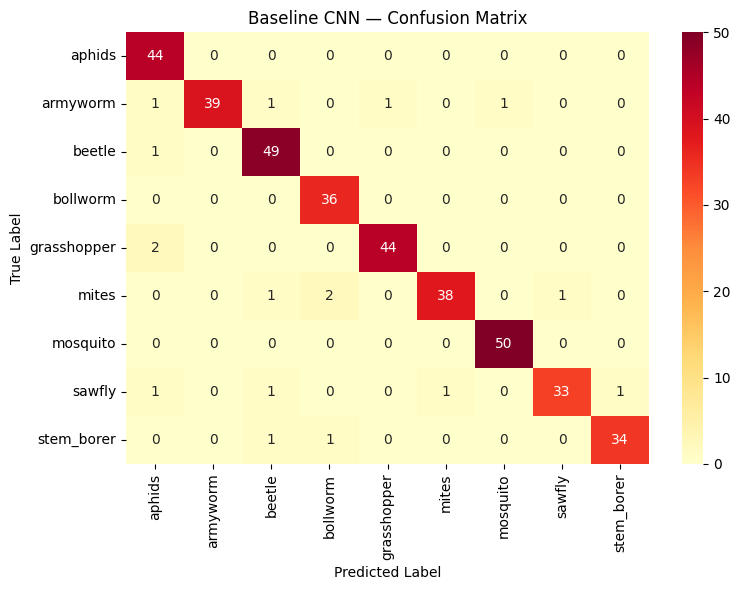

In [29]:
plot_confusion_matrix(
    baseline_true, baseline_pred,
    evaluation_ds.class_names,
    title="Baseline CNN — Confusion Matrix",
    cmap_name='YlOrRd'
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


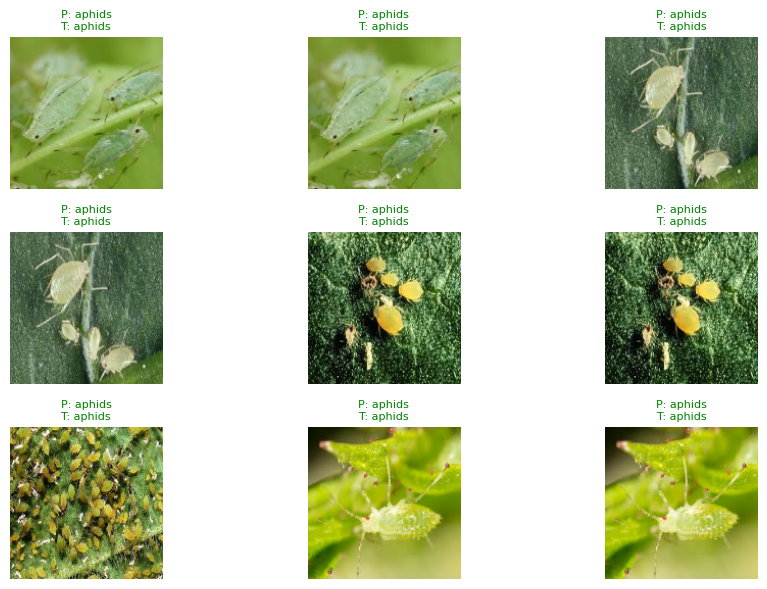

In [30]:
plot_sample_predictions(
    baseline_cnn,
    evaluation_ds,
    class_names=all_categories
)

## Section 6: Deep CNN Model (Adam Optimizer)

In [31]:
def build_deep_cnn(num_cls, aug_layers):
    """
    Constructs a deeper 4-block CNN with BatchNorm and Dropout for regularization.
    """
    mdl = keras.Sequential([
        layers.Input(shape=(IMG_DIM, IMG_DIM, 3)),
        *aug_layers,
        layers.Rescaling(1.0 / 255),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.1),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.1),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(num_cls, activation='softmax'),
    ])
    return mdl

deep_adam_cnn = build_deep_cnn(NUM_CLASSES, augment_pipeline)

In [32]:
deep_adam_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
deep_adam_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 150, 150, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 74, 74, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 3,838,889 (14.64 MB)

 Trainable params: 3,837,161 (14.64 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [33]:
stop_early2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr2  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [34]:
deep_start_time = time.time()

deep_adam_log = deep_adam_cnn.fit(
    training_ds,
    validation_data=validation_ds,
    epochs=40,
    callbacks=[stop_early2, reduce_lr2],
    class_weight=class_weights
)
deep_end_time = time.time()
print(f"Training Time: {deep_end_time - deep_start_time} seconds")

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.1962 - loss: 2.3563 - val_accuracy: 0.1220 - val_loss: 2.8671 - learning_rate: 0.0010
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.2907 - loss: 2.0099 - val_accuracy: 0.1100 - val_loss: 3.2688 - learning_rate: 0.0010
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.3559 - loss: 1.8440 - val_accuracy: 0.1077 - val_loss: 3.4857 - learning_rate: 0.0010
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.4139 - loss: 1.6856 - val_accuracy: 0.1411 - val_loss: 2.4437 - learning_rate: 0.0010
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 0.4575 - loss: 1.5409 - val_accuracy: 0.1603 - val_loss: 2.8757 - learning_rate: 0.0010
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.5102 - loss: 1.4342 - val_accuracy: 0.2225 - val_loss: 2.5760 - learning_rate: 0.0010
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.5191 - loss: 1.398

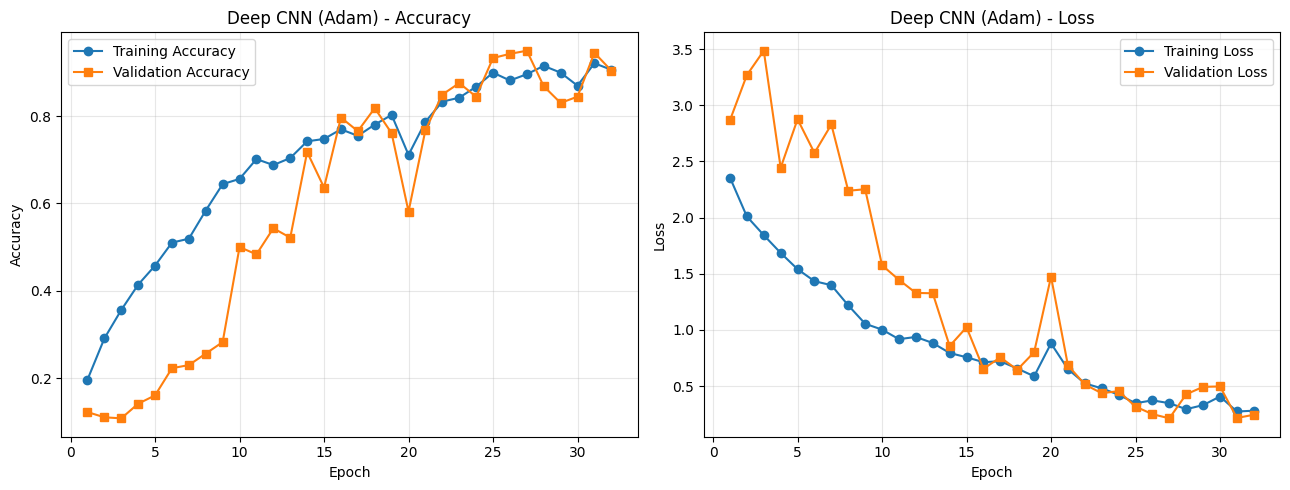

In [35]:
plot_training_curves(deep_adam_log, title_prefix="Deep CNN (Adam)")

In [36]:

deep_adam_true, deep_adam_pred = run_evaluation(deep_adam_cnn, evaluation_ds, "Deep CNN (Adam)")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step

  Classification Report — Deep CNN (Adam)
              precision    recall  f1-score   support

      aphids       0.85      0.93      0.89        44
    armyworm       0.97      0.88      0.93        43
      beetle       1.00      0.94      0.97        50
    bollworm       0.95      0.97      0.96        36
 grasshopper       0.88      0.96      0.92        46
       mites       0.93      0.95      0.94        42
    mosquito       0.98      0.96      0.97        50
      sawfly       0.91      0.86      0.89        37
  stem_borer       0.97      0.97      0.97        36

    accuracy                           0.94       384
   macro avg       0.94      0.94      0.94       384
weighted avg       0.94      0.94      0.94       384



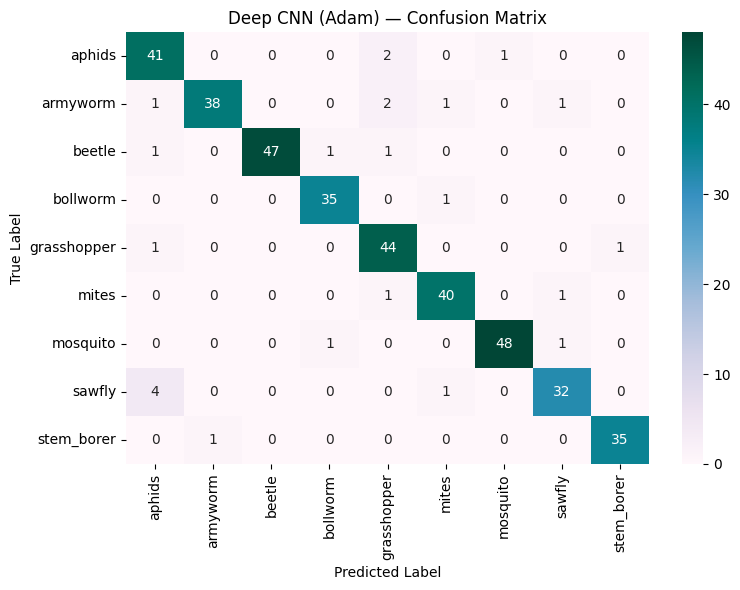

In [37]:
plot_confusion_matrix(
    deep_adam_true, deep_adam_pred,
    evaluation_ds.class_names,
    title="Deep CNN (Adam) — Confusion Matrix",
    cmap_name='PuBuGn'
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step


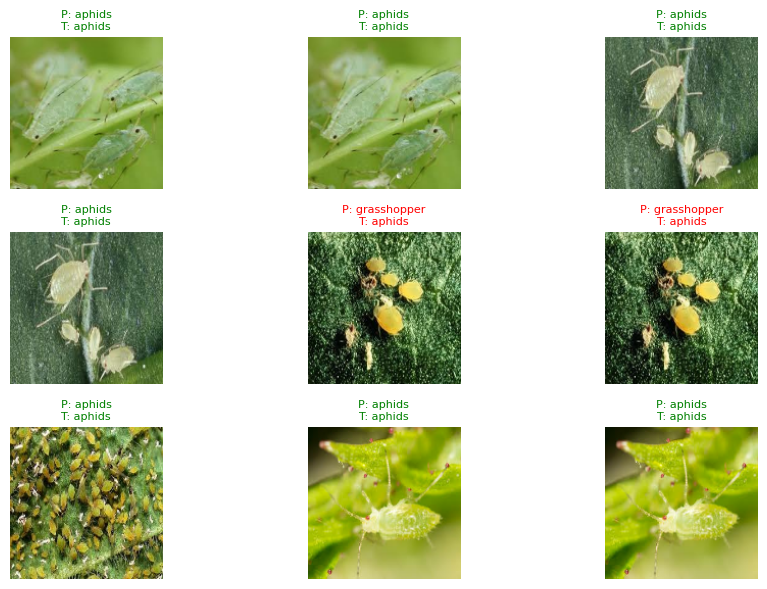

In [38]:
plot_sample_predictions(
    deep_adam_cnn,
    evaluation_ds,
    class_names=all_categories
)

## Convergence comparison — Baseline vs Deep (Adam)

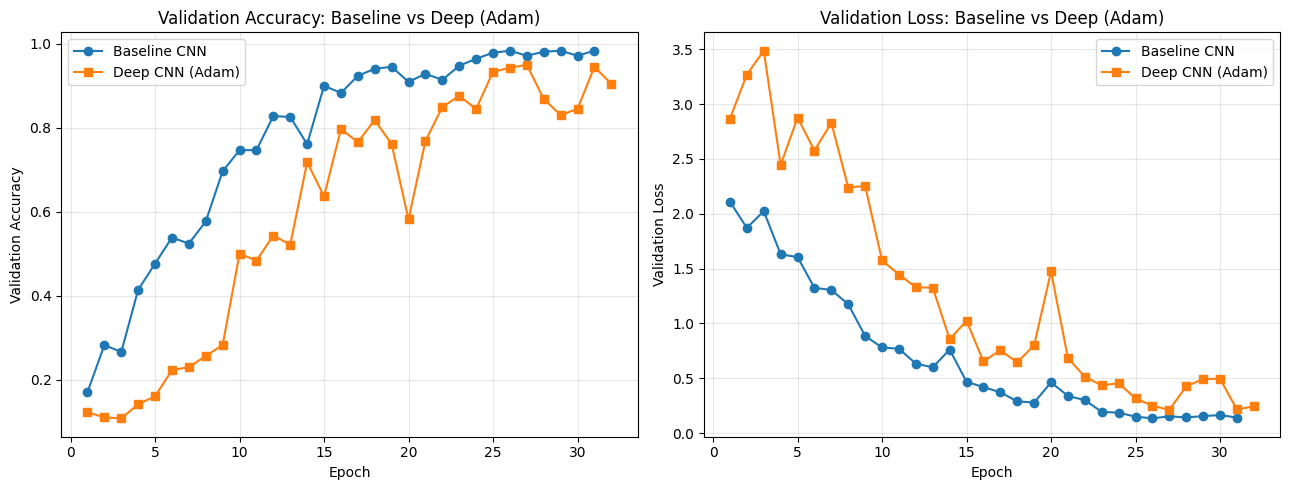

Figure saved: comparison_baseline_vs_deep.png


In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

b_epochs = range(1, len(baseline_log.history['val_accuracy']) + 1)
d_epochs = range(1, len(deep_adam_log.history['val_accuracy']) + 1)

ax1.plot(b_epochs, baseline_log.history['val_accuracy'],  label='Baseline CNN',      marker='o', linewidth=1.5)
ax1.plot(d_epochs, deep_adam_log.history['val_accuracy'], label='Deep CNN (Adam)',    marker='s', linewidth=1.5)
ax1.set_title("Validation Accuracy: Baseline vs Deep (Adam)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Validation Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(b_epochs, baseline_log.history['val_loss'],  label='Baseline CNN',    marker='o', linewidth=1.5)
ax2.plot(d_epochs, deep_adam_log.history['val_loss'], label='Deep CNN (Adam)', marker='s', linewidth=1.5)
ax2.set_title("Validation Loss: Baseline vs Deep (Adam)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Validation Loss")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_baseline_vs_deep.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: comparison_baseline_vs_deep.png")

In [85]:
# Re-evaluate every model on the test set and record accuracy
baseline_loss,    baseline_acc    = baseline_cnn.evaluate(evaluation_ds,   verbose=0)
deep_adam_loss,   deep_adam_acc   = deep_adam_cnn.evaluate(evaluation_ds,  verbose=0)

model_names   = ["Baseline CNN", "Deep CNN\n(Adam)"]
test_accs     = [baseline_acc, deep_adam_acc]
test_losses   = [baseline_loss, deep_adam_loss]
test_times    = [baseline_end_time - baseline_start_time,
                 deep_end_time - deep_start_time]

print("=" * 68)
print(f"{'Model':<28} {'Test Acc':>10} {'Test Loss':>12} {'Time(s)':>10}")
print("=" * 68)

for name, acc, loss, t in zip(model_names, test_accs, test_losses, test_times):
    clean = name.replace('\n', ' ')
    print(f"{clean:<28} {acc:>10.4f} {loss:>12.4f} {t:>10.2f}")

print("=" * 68)

Model                          Test Acc    Test Loss    Time(s)
Baseline CNN                     0.9557       0.2899     256.29
Deep CNN (Adam)                  0.9375       0.2993     308.19


##Section 7: Deep CNN Model (SGD + Momentum)

In [41]:
deep_sgd_cnn = build_deep_cnn(NUM_CLASSES, augment_pipeline)

deep_sgd_cnn.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
deep_sgd_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 150, 150, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 74, 74, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 3,838,889 (14.64 MB)

 Trainable params: 3,837,161 (14.64 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [42]:
stop_early3 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr3  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)


In [43]:
sgd_start_time = time.time()

deep_sgd_log = deep_sgd_cnn.fit(
    training_ds,
    validation_data=validation_ds,
    epochs=40,
    callbacks=[stop_early3, reduce_lr3],
    class_weight=class_weights
)

sgd_end_time = time.time()
print(f"Training Time: {sgd_end_time - sgd_start_time} seconds")

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - accuracy: 0.2177 - loss: 2.2985 - val_accuracy: 0.1292 - val_loss: 4.9282 - learning_rate: 0.0100
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.2751 - loss: 2.0083 - val_accuracy: 0.2368 - val_loss: 2.4271 - learning_rate: 0.0100
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.3415 - loss: 1.8954 - val_accuracy: 0.2129 - val_loss: 2.0991 - learning_rate: 0.0100
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.3726 - loss: 1.7877 - val_accuracy: 0.3301 - val_loss: 1.9488 - learning_rate: 0.0100
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.3959 - loss: 1.7002 - val_accuracy: 0.2560 - val_loss: 2.4368 - learning_rate: 0.0100
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.4234 - loss: 1.6313 - val_accuracy: 0.3349 - val_loss: 1.8060 - learning_rate: 0.0100
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.4617 - loss: 1.5317 

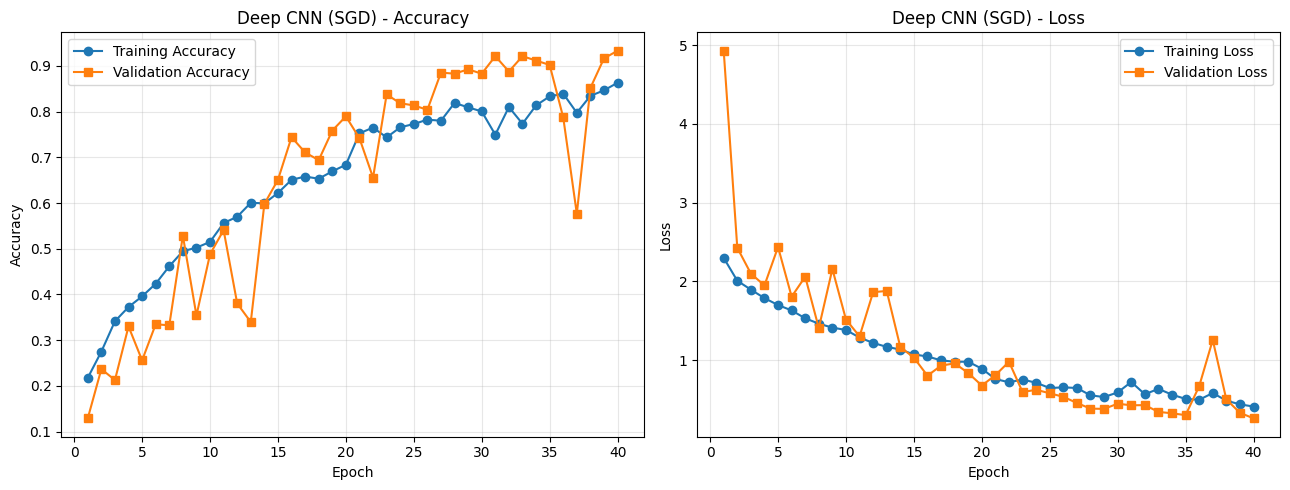

In [44]:
plot_training_curves(deep_sgd_log, title_prefix="Deep CNN (SGD)")

In [45]:
sgd_loss, sgd_acc = deep_sgd_cnn.evaluate(evaluation_ds)
print(f"\nSGD Model — Test Accuracy: {sgd_acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9323 - loss: 0.3050

SGD Model — Test Accuracy: 0.9323


In [46]:
deep_sgd_true, deep_sgd_pred = run_evaluation(deep_sgd_cnn, evaluation_ds, "Deep CNN (SGD)")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step

  Classification Report — Deep CNN (SGD)
              precision    recall  f1-score   support

      aphids       0.88      0.95      0.91        44
    armyworm       0.90      0.84      0.87        43
      beetle       0.98      0.92      0.95        50
    bollworm       0.95      1.00      0.97        36
 grasshopper       0.90      0.98      0.94        46
       mites       0.95      0.93      0.94        42
    mosquito       0.94      0.94      0.94        50
      sawfly       0.94      0.89      0.92        37
  stem_borer       0.97      0.94      0.96        36

    accuracy                           0.93       384
   macro avg       0.93      0.93      0.93       384
weighted avg       0.93      0.93      0.93       384



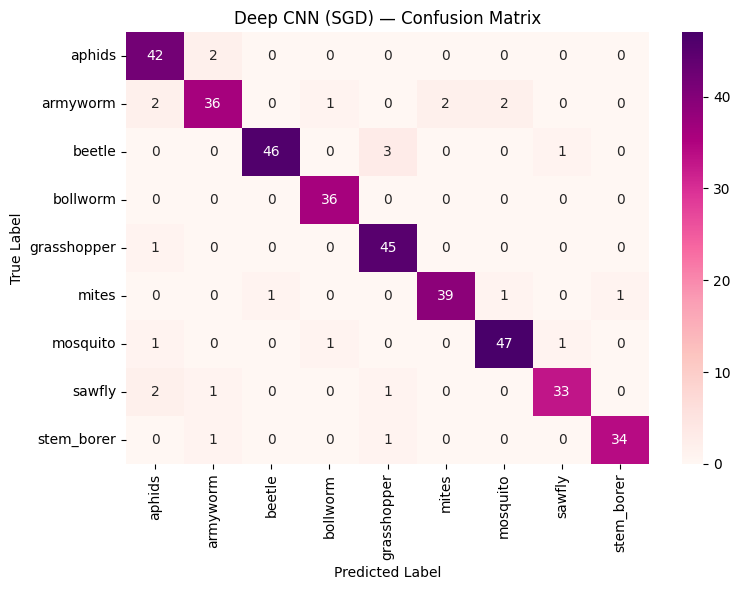

In [47]:
plot_confusion_matrix(
    deep_sgd_true, deep_sgd_pred,
    evaluation_ds.class_names,
    title="Deep CNN (SGD) — Confusion Matrix",
    cmap_name='RdPu'
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


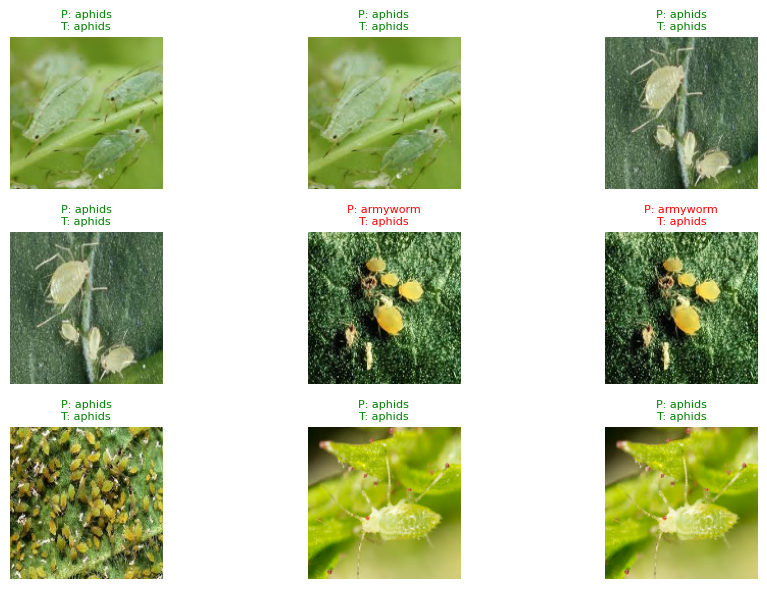

In [48]:
plot_sample_predictions(
    deep_sgd_cnn,
    evaluation_ds,
    class_names=all_categories
)

##  Optimizer comparison — Adam vs SGD (same deep architecture)

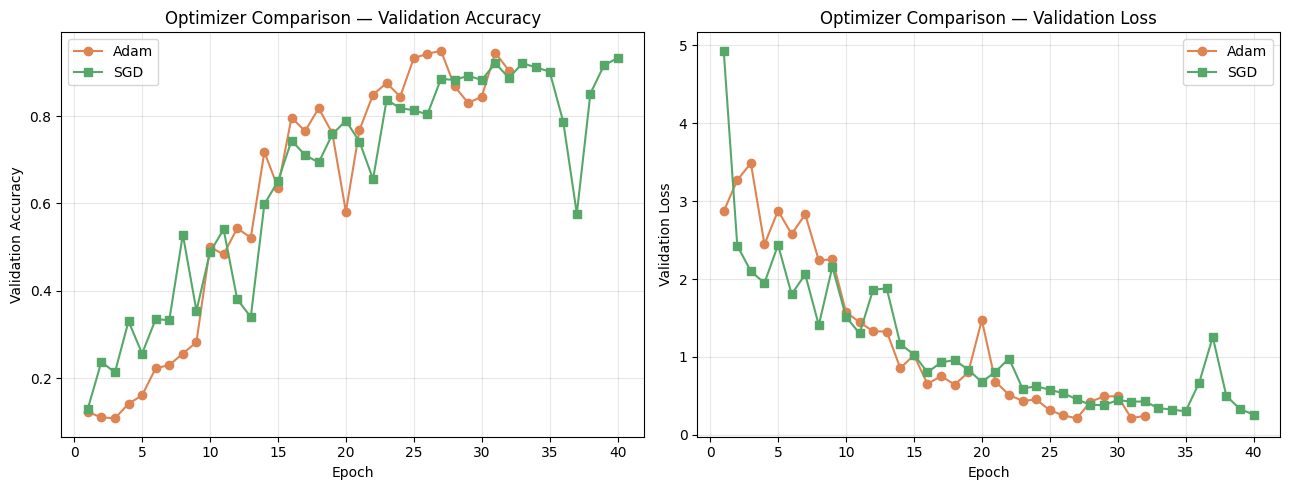

Figure saved: comparison_adam_vs_sgd.png


In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

a_epochs = range(1, len(deep_adam_log.history['val_accuracy']) + 1)
s_epochs = range(1, len(deep_sgd_log.history['val_accuracy']) + 1)

ax1.plot(a_epochs, deep_adam_log.history['val_accuracy'], label='Adam',  marker='o', color='#DD8452', linewidth=1.5)
ax1.plot(s_epochs, deep_sgd_log.history['val_accuracy'],  label='SGD',   marker='s', color='#55A868', linewidth=1.5)
ax1.set_title("Optimizer Comparison — Validation Accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Validation Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(a_epochs, deep_adam_log.history['val_loss'], label='Adam', marker='o', color='#DD8452', linewidth=1.5)
ax2.plot(s_epochs, deep_sgd_log.history['val_loss'],  label='SGD',  marker='s', color='#55A868', linewidth=1.5)
ax2.set_title("Optimizer Comparison — Validation Loss")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Validation Loss")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_adam_vs_sgd.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: comparison_adam_vs_sgd.png")

In [50]:
deep_adam_loss,   deep_adam_acc   = deep_adam_cnn.evaluate(evaluation_ds,  verbose=0)
deep_sgd_loss,    deep_sgd_acc    = deep_sgd_cnn.evaluate(evaluation_ds,   verbose=0)

model_names  = ["Deep CNN\n(Adam)", "Deep CNN\n(SGD)"]
test_accs    = [deep_adam_acc, deep_sgd_acc]
test_losses  = [deep_adam_loss, deep_sgd_loss]
test_times   = [deep_end_time - deep_start_time, sgd_end_time - sgd_start_time]

print("=" * 64)
print(f"{'Model':<28} {'Test Acc':>10} {'Test Loss':>12} {'Time(s)':>10}")
print("=" * 64)
for name, acc, loss, t in zip(model_names, test_accs, test_losses, test_times):
    clean = name.replace('\n', ' ')
    print(f"{clean:<28} {acc:>10.4f} {loss:>12.4f} {t:>10.2f}")
print("=" * 64)

Model                          Test Acc    Test Loss    Time(s)
Deep CNN (Adam)                  0.9375       0.2993     308.19
Deep CNN (SGD)                   0.9323       0.3050     341.10


### Comparison of Adam vs. SGD Optimizers

Based on the validation accuracy and loss curves for the deeper CNN trained using Adam and SGD:

*   **Convergence Speed:** The Adam optimizer converges noticeably faster than SGD. In the plots, the Adam-based model quickly improves its validation accuracy and reduces validation loss within the early epochs, stabilizing relatively early. In contrast, SGD shows a slower and more gradual learning pattern across epochs.

*   **Final Accuracy and Loss:** Although SGD may sometimes achieve a better local minimum and potentially higher final accuracy and lower loss with sufficient training time and proper tuning, in this comparison the Adam optimizer achieves a clearly higher final validation accuracy and a lower validation loss within the given epochs. The SGD model seems to plateau earlier, suggesting it may be stuck in a suboptimal region or may require more aggressive learning rate scheduling or extended training.

Overall, Adam outperforms SGD in this setup, both in terms of faster convergence and better final performance for the deeper CNN model under the given training conditions.

##   Section 8:  Ablation Study
##       Train the deep model WITHOUT Dropout+BatchNorm, compare

In [51]:
print("\n--- Ablation Study: Deep CNN without Dropout and BatchNorm ---")

def build_ablation_cnn(num_cls, aug_layers):
    """Deep CNN without any Dropout or BatchNormalization layers."""
    mdl = keras.Sequential([
        layers.Input(shape=(IMG_DIM, IMG_DIM, 3)),
        *aug_layers,
        layers.Rescaling(1.0 / 255),
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(),
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(),
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(),
        # Block 4
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        # Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),

        layers.Dense(64, activation='relu'),
        layers.Dense(num_cls, activation='softmax'),
    ])
    return mdl

ablation_cnn = build_ablation_cnn(NUM_CLASSES, augment_pipeline)


--- Ablation Study: Deep CNN without Dropout and BatchNorm ---


In [52]:
ablation_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ablation_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 150, 150, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     5,308,67

 Total params: 5,936,041 (22.64 MB)

 Trainable params: 5,934,313 (22.64 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [53]:
ablation_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ablation_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [54]:
deep_no_dropout_start_time = time.time()

ablation_log = ablation_cnn.fit(
    training_ds,
    validation_data=validation_ds,
    epochs=40,
    callbacks=[ablation_stop, ablation_lr],
    class_weight=class_weights
)

deep_no_dropout_end_time = time.time()
print(f"Training Time: {deep_no_dropout_end_time - deep_no_dropout_start_time} seconds")

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.2853 - loss: 2.0633 - val_accuracy: 0.1268 - val_loss: 2.8034 - learning_rate: 0.0010
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.4533 - loss: 1.5905 - val_accuracy: 0.0909 - val_loss: 2.8010 - learning_rate: 0.0010
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.5251 - loss: 1.3848 - val_accuracy: 0.1100 - val_loss: 3.1794 - learning_rate: 0.0010
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.6160 - loss: 1.1430 - val_accuracy: 0.1627 - val_loss: 2.8368 - learning_rate: 0.0010
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.6980 - loss: 0.9529 - val_accuracy: 0.1411 - val_loss: 2.8717 - learning_rate: 0.0010
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.7656 - loss: 0.7265 - val_accuracy: 0.2057 - val_loss: 2.8811 - learning_rate: 5.0000e-04
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.8427 - loss: 0.57

In [86]:
ablation_true, ablation_pred = run_evaluation(ablation_cnn, evaluation_ds, "Ablation CNN")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step

  Classification Report — Ablation CNN
              precision    recall  f1-score   support

      aphids       0.92      1.00      0.96        44
    armyworm       0.95      0.91      0.93        43
      beetle       0.98      0.98      0.98        50
    bollworm       1.00      1.00      1.00        36
 grasshopper       0.90      0.98      0.94        46
       mites       1.00      0.93      0.96        42
    mosquito       0.98      0.98      0.98        50
      sawfly       0.94      0.89      0.92        37
  stem_borer       0.97      0.94      0.96        36

    accuracy                           0.96       384
   macro avg       0.96      0.96      0.96       384
weighted avg       0.96      0.96      0.96       384



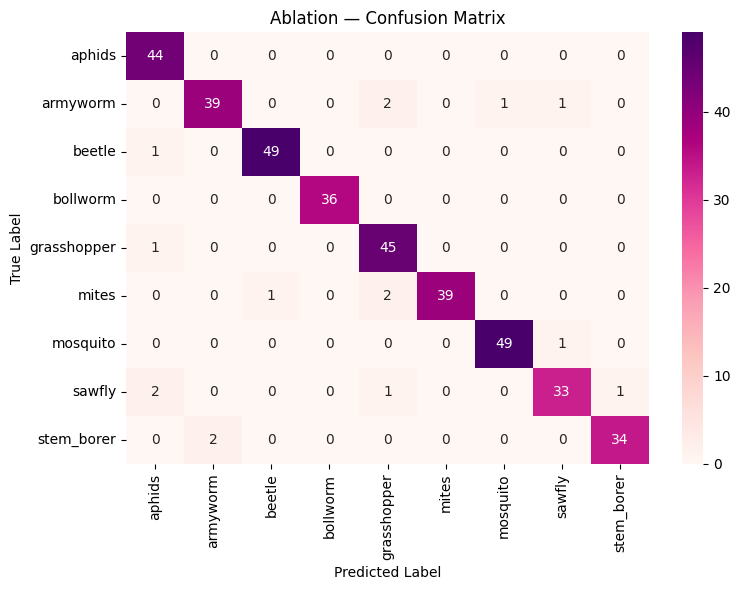

In [87]:
plot_confusion_matrix(
    ablation_true, ablation_pred,
    evaluation_ds.class_names,
    title="Ablation — Confusion Matrix",
    cmap_name='RdPu'
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step


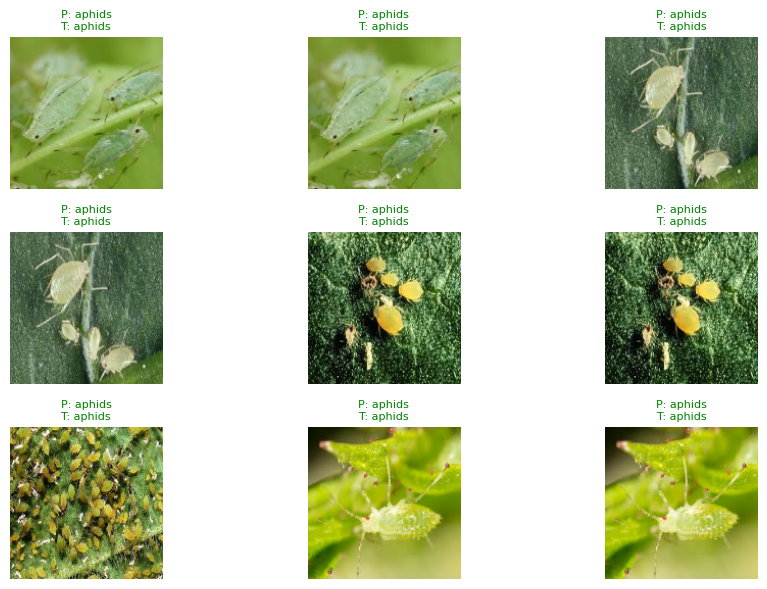

In [55]:
plot_sample_predictions(
    ablation_cnn,
    evaluation_ds,
    class_names=all_categories
)

In [56]:
abl_loss, abl_acc = ablation_cnn.evaluate(evaluation_ds, verbose=0)
deep_adam_loss, deep_adam_acc = deep_adam_cnn.evaluate(evaluation_ds, verbose=0)

model_names  = ["Ablation CNN\n(No Dropout)", "Deep CNN\n(Dropout)"]
test_accs    = [abl_acc, deep_adam_acc]
test_losses  = [abl_loss, deep_adam_loss]
test_times   = [deep_no_dropout_end_time - deep_no_dropout_start_time,
                 deep_end_time - deep_start_time]

print("=" * 72)
print(f"{'Model':<30} {'Test Acc':>10} {'Test Loss':>12} {'Time(s)':>12}")
print("=" * 72)

for name, acc, loss, t in zip(model_names, test_accs, test_losses, test_times):
    clean = name.replace('\n', ' ')
    print(f"{clean:<30} {acc:>10.4f} {loss:>12.4f} {t:>12.2f}")

print("=" * 72)

print(f"\nImprovement from regularization: {(deep_adam_acc - abl_acc)*100:+.2f}%")

Model                            Test Acc    Test Loss      Time(s)
Ablation CNN (No Dropout)          0.9583       0.1885       302.44
Deep CNN (Dropout)                 0.9375       0.2993       308.19

Improvement from regularization: -2.08%


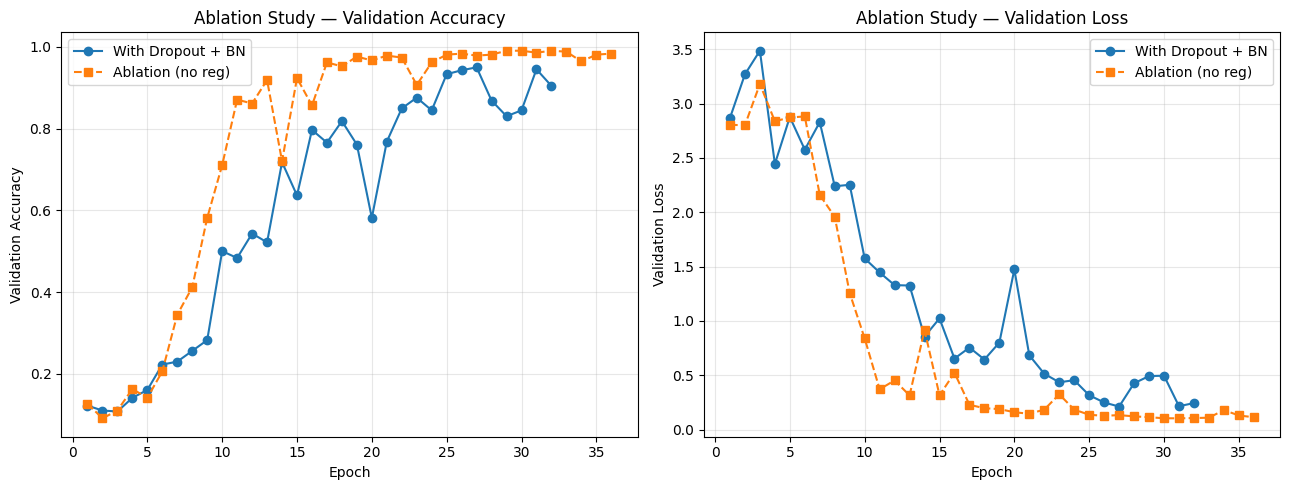

Figure saved: ablation_study.png


In [57]:
# Ablation convergence plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
abl_ep  = range(1, len(ablation_log.history['val_accuracy']) + 1)
deep_ep = range(1, len(deep_adam_log.history['val_accuracy']) + 1)

ax1.plot(deep_ep, deep_adam_log.history['val_accuracy'], label='With Dropout + BN', marker='o', linewidth=1.5)
ax1.plot(abl_ep,  ablation_log.history['val_accuracy'],  label='Ablation (no reg)', marker='s', linestyle='--', linewidth=1.5)
ax1.set_title("Ablation Study — Validation Accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Validation Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(deep_ep, deep_adam_log.history['val_loss'], label='With Dropout + BN', marker='o', linewidth=1.5)
ax2.plot(abl_ep,  ablation_log.history['val_loss'],  label='Ablation (no reg)', marker='s', linestyle='--', linewidth=1.5)
ax2.set_title("Ablation Study — Validation Loss")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Validation Loss")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: ablation_study.png")

## Section 9:Transfer Learning — Fine-Tuning MobileNetV2

In [58]:
FINETUNE_IMG_DIM = 224
FINETUNE_BATCH   = 32

In [59]:
ft_train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED_VAL,
    image_size=(FINETUNE_IMG_DIM, FINETUNE_IMG_DIM),
    batch_size=FINETUNE_BATCH
)

ft_val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED_VAL,
    image_size=(FINETUNE_IMG_DIM, FINETUNE_IMG_DIM),
    batch_size=FINETUNE_BATCH
)

ft_test_ds = keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(FINETUNE_IMG_DIM, FINETUNE_IMG_DIM),
    batch_size=FINETUNE_BATCH,
    shuffle=False
)

Found 2090 files belonging to 9 classes.
Using 1672 files for training.
Found 2090 files belonging to 9 classes.
Using 418 files for validation.
Found 384 files belonging to 9 classes.


In [60]:
ft_augment = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
]

In [61]:
# Load MobileNetV2 backbone (frozen)
backbone = keras.applications.MobileNetV2(
    input_shape=(FINETUNE_IMG_DIM, FINETUNE_IMG_DIM, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [62]:
backbone.trainable = False  # Freeze pretrained weights

In [63]:
FT_NUM_CLASSES = len(ft_train_ds.class_names)

# Build fine-tune model
finetune_model = keras.Sequential([
    layers.Input(shape=(FINETUNE_IMG_DIM, FINETUNE_IMG_DIM, 3)),
    *ft_augment,
    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),
    backbone,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(FT_NUM_CLASSES, activation='softmax'),
])

In [64]:
finetune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
finetune_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,233 (9.26 MB)

 Trainable params: 167,689 (655.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [65]:
stop_early4 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr4  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [66]:
finetune_start = time.time()

finetune_log = finetune_model.fit(
    ft_train_ds,
    validation_data=ft_val_ds,
    epochs=20,
    callbacks=[stop_early4, reduce_lr4],
    class_weight=class_weights
)

finetune_end_time = time.time()
print(f"Training Time: {finetune_end_time - finetune_start} seconds")

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 195ms/step - accuracy: 0.4689 - loss: 1.8192 - val_accuracy: 0.7392 - val_loss: 0.8908 - learning_rate: 5.0000e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.7309 - loss: 0.8304 - val_accuracy: 0.8589 - val_loss: 0.5313 - learning_rate: 5.0000e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.8068 - loss: 0.6004 - val_accuracy: 0.9211 - val_loss: 0.3357 - learning_rate: 5.0000e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 147ms/step - accuracy: 0.8702 - loss: 0.4238 - val_accuracy: 0.9402 - val_loss: 0.2510 - learning_rate: 5.0000e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.8798 - loss: 0.3693 - val_accuracy: 0.9569 - val_loss: 0.1836 - learning_rate: 5.0000e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.8876 - loss: 0.3428 - val_accuracy: 0.9617 - val_loss: 0.1520 - learning_rate: 5.0000e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accurac

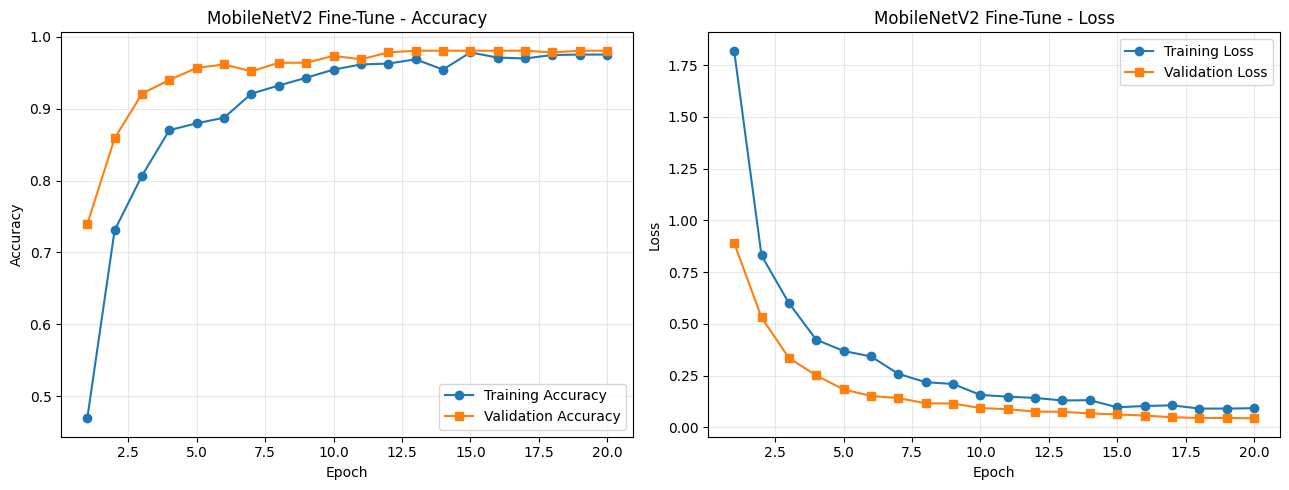

In [67]:
plot_training_curves(finetune_log, title_prefix="MobileNetV2 Fine-Tune")

In [68]:
ft_true, ft_pred = run_evaluation(finetune_model, ft_test_ds, "MobileNetV2 Fine-Tune")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step

  Classification Report — MobileNetV2 Fine-Tune
              precision    recall  f1-score   support

      aphids       0.94      1.00      0.97        44
    armyworm       0.98      0.98      0.98        43
      beetle       1.00      0.98      0.99        50
    bollworm       0.97      1.00      0.99        36
 grasshopper       1.00      1.00      1.00        46
       mites       1.00      1.00      1.00        42
    mosquito       1.00      1.00      1.00        50
      sawfly       0.97      0.89      0.93        37
  stem_borer       0.97      0.97      0.97        36

    accuracy                           0.98       384
   macro avg       0.98      0.98      0.98       384
weighted avg       0.98      0.98      0.98       384



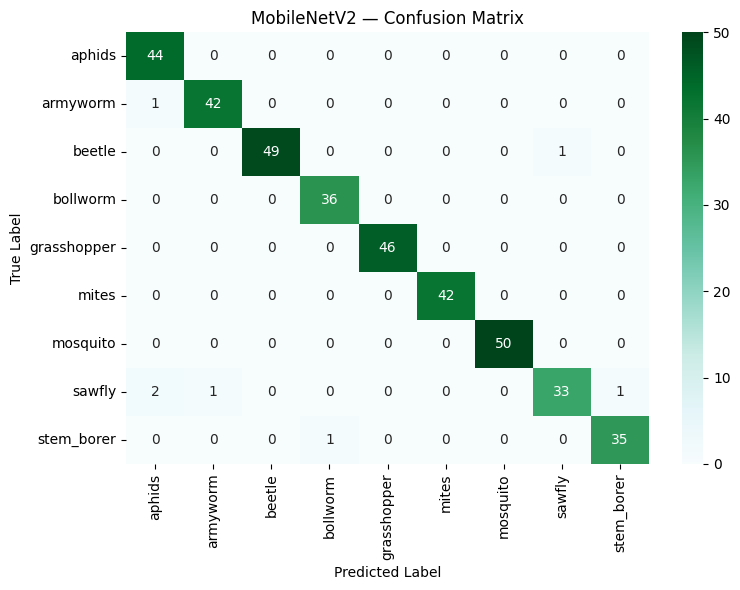

In [69]:
plot_confusion_matrix(
    ft_true, ft_pred,
    ft_test_ds.class_names,
    title="MobileNetV2 — Confusion Matrix",
    cmap_name='BuGn'
)

##Section 10: Full Fine-Tuning — Unfreeze Top Layers

In [70]:
# Unfreeze the backbone
backbone.trainable = True

# Keep lower feature-extraction layers frozen; only train the top 30
for lyr in backbone.layers[:-30]:
    lyr.trainable = False

In [71]:
finetune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # small LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
stop_early5 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr5  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [73]:
full_finetune_start = time.time()
full_finetune_log = finetune_model.fit(
    ft_train_ds,
    validation_data=ft_val_ds,
    epochs=20,
    callbacks=[stop_early5, reduce_lr5],
    class_weight=class_weights
)
full_finetune_end_time = time.time()
print(f"Training Time: {full_finetune_end_time - full_finetune_start} seconds")

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.9121 - loss: 0.2752 - val_accuracy: 0.9641 - val_loss: 0.1334 - learning_rate: 1.0000e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.9456 - loss: 0.1711 - val_accuracy: 0.9617 - val_loss: 0.1494 - learning_rate: 1.0000e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.9677 - loss: 0.1005 - val_accuracy: 0.9617 - val_loss: 0.1307 - learning_rate: 1.0000e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - accuracy: 0.9803 - loss: 0.0678 - val_accuracy: 0.9593 - val_loss: 0.1371 - learning_rate: 1.0000e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.9695 - loss: 0.0890 - val_accuracy: 0.9617 - val_loss: 0.1511 - learning_rate: 1.0000e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.9809 - loss: 0.0675 - val_accuracy: 0.9689 - val_loss: 0.1300 - learning_rate: 1.0000e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy:

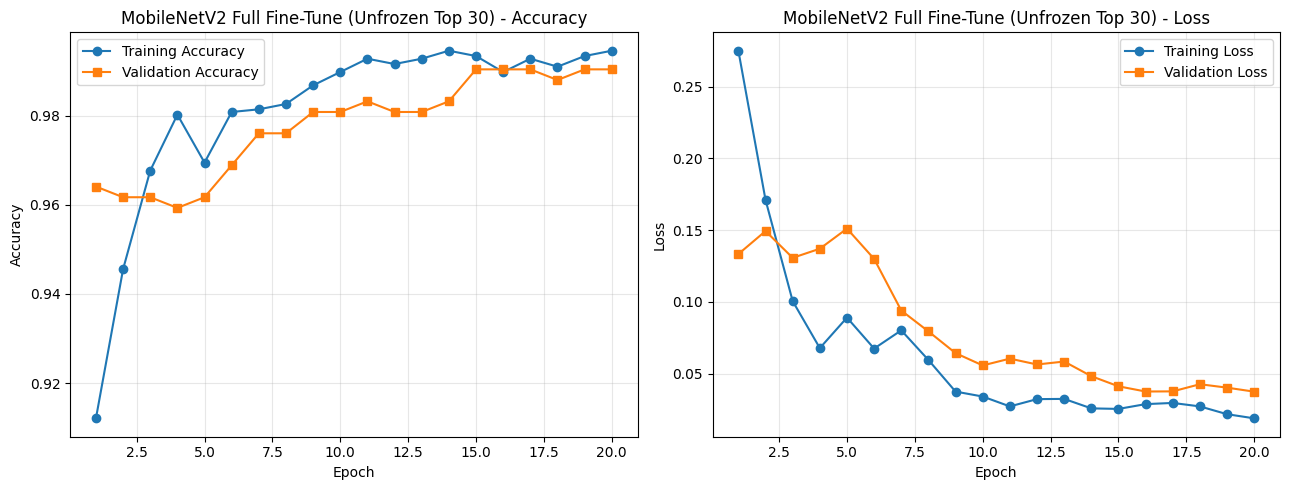

In [74]:
plot_training_curves(full_finetune_log, title_prefix="MobileNetV2 Full Fine-Tune (Unfrozen Top 30)")

In [75]:
full_ft_true, full_ft_pred = run_evaluation(
    finetune_model, ft_test_ds,
    "MobileNetV2 Full Fine-Tune"
)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step

  Classification Report — MobileNetV2 Full Fine-Tune
              precision    recall  f1-score   support

      aphids       0.94      1.00      0.97        44
    armyworm       1.00      0.98      0.99        43
      beetle       1.00      0.98      0.99        50
    bollworm       0.97      1.00      0.99        36
 grasshopper       1.00      1.00      1.00        46
       mites       0.98      1.00      0.99        42
    mosquito       1.00      1.00      1.00        50
      sawfly       0.97      0.95      0.96        37
  stem_borer       1.00      0.94      0.97        36

    accuracy                           0.98       384
   macro avg       0.98      0.98      0.98       384
weighted avg       0.98      0.98      0.98       384



In [76]:
ft_final_loss, ft_final_acc = finetune_model.evaluate(ft_test_ds)
print(f"\nFull Fine-Tune — Test Accuracy: {ft_final_acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9844 - loss: 0.1787

Full Fine-Tune — Test Accuracy: 0.9844


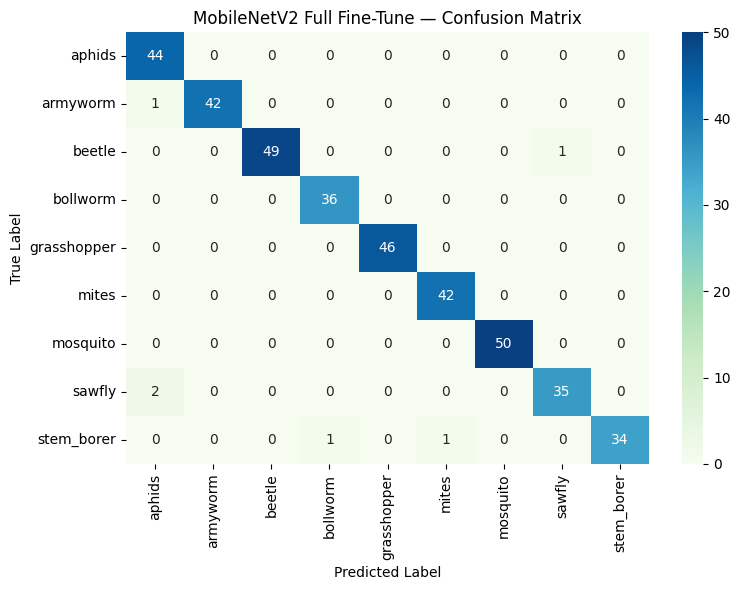

In [77]:
plot_confusion_matrix(
    full_ft_true, full_ft_pred,
    ft_test_ds.class_names,
    title="MobileNetV2 Full Fine-Tune — Confusion Matrix",
    cmap_name='GnBu'
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


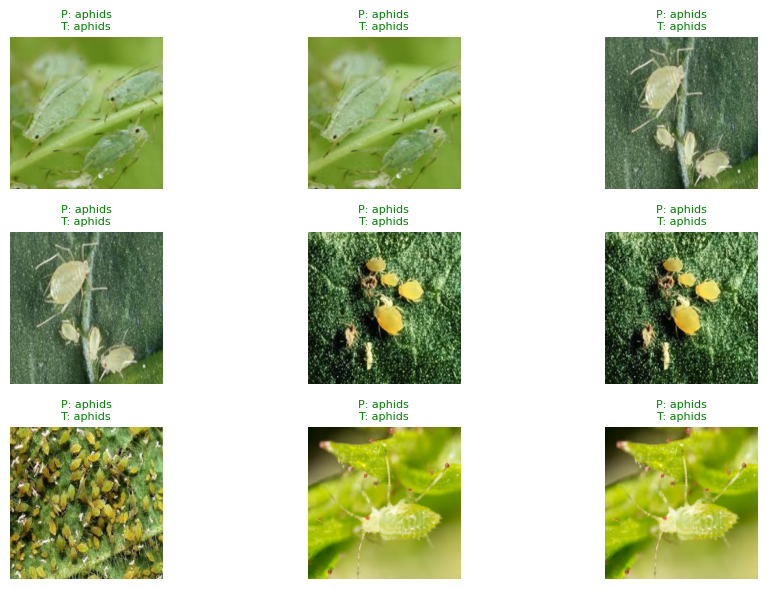

In [78]:
plot_sample_predictions(
    finetune_model,
    ft_test_ds,
    class_names=all_categories
)

 ## Section 11: Comparative Analysis

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.metrics import accuracy_score
import time

## Final test accuracies for all models

In [80]:
# Re-evaluate every model on the test set and record accuracy
baseline_loss,    baseline_acc    = baseline_cnn.evaluate(evaluation_ds,   verbose=0)
deep_adam_loss,   deep_adam_acc   = deep_adam_cnn.evaluate(evaluation_ds,  verbose=0)
deep_sgd_loss,    deep_sgd_acc    = deep_sgd_cnn.evaluate(evaluation_ds,   verbose=0)
ft_loss,          ft_acc          = finetune_model.evaluate(ft_test_ds,     verbose=0)

model_names  = ["Baseline CNN", "Deep CNN\n(Adam)", "Deep CNN\n(SGD)", "MobileNetV2\n(Fine-Tuned)"]
test_accs    = [baseline_acc,   deep_adam_acc,       deep_sgd_acc,      ft_acc]
test_losses  = [baseline_loss,  deep_adam_loss,      deep_sgd_loss,     ft_loss]

print("=" * 52)
print(f"{'Model':<28} {'Test Acc':>10} {'Test Loss':>10}")
print("=" * 52)
for name, acc, loss in zip(model_names, test_accs, test_losses):
    clean = name.replace('\n', ' ')
    print(f"{clean:<28} {acc:>10.4f} {loss:>10.4f}")
print("=" * 52)

Model                          Test Acc  Test Loss
Baseline CNN                     0.9557     0.2899
Deep CNN (Adam)                  0.9375     0.2993
Deep CNN (SGD)                   0.9323     0.3050
MobileNetV2 (Fine-Tuned)         0.9844     0.1787


## Bar chart - test accuracy comparison across all models

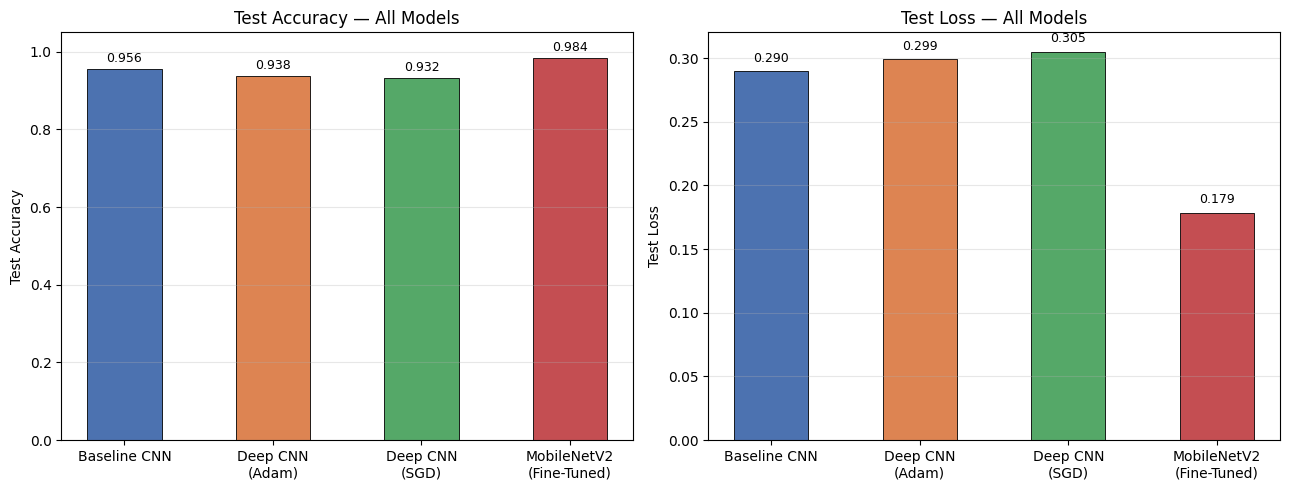

Figure saved: comparison_accuracy_loss.png


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy bar
bars = axes[0].bar(model_names, test_accs, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
                   edgecolor='black', linewidth=0.6, width=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Test Accuracy — All Models")
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f"{acc:.3f}", ha='center', va='bottom', fontsize=9)
# Loss bar
bars2 = axes[1].bar(model_names, test_losses, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
                    edgecolor='black', linewidth=0.6, width=0.5)
axes[1].set_ylabel("Test Loss")
axes[1].set_title("Test Loss — All Models")
axes[1].grid(axis='y', alpha=0.3)
for bar, loss in zip(bars2, test_losses):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f"{loss:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("comparison_accuracy_loss.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: comparison_accuracy_loss.png")

## Transfer Learning vs Scratch - final summary bar chart

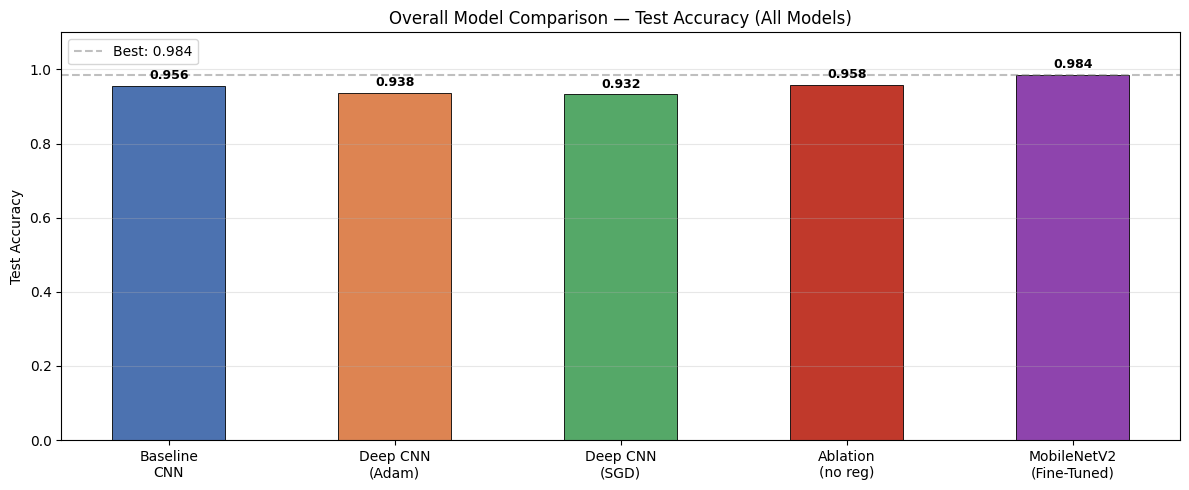

Figure saved: overall_model_comparison.png


In [82]:
all_names   = ["Baseline\nCNN", "Deep CNN\n(Adam)", "Deep CNN\n(SGD)", "Ablation\n(no reg)", "MobileNetV2\n(Fine-Tuned)"]
all_accs    = [baseline_acc, deep_adam_acc, deep_sgd_acc, abl_acc, ft_acc]
colors      = ['#4C72B0', '#DD8452', '#55A868', '#c0392b', '#8E44AD']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(all_names, all_accs, color=colors, edgecolor='black', linewidth=0.6, width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Test Accuracy")
ax.set_title("Overall Model Comparison — Test Accuracy (All Models)")
ax.axhline(y=max(all_accs), color='gray', linestyle='--', alpha=0.5, label=f"Best: {max(all_accs):.3f}")
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{acc:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("overall_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: overall_model_comparison.png")

## Validation Accuracy & Loss Comparison (Line Plot)

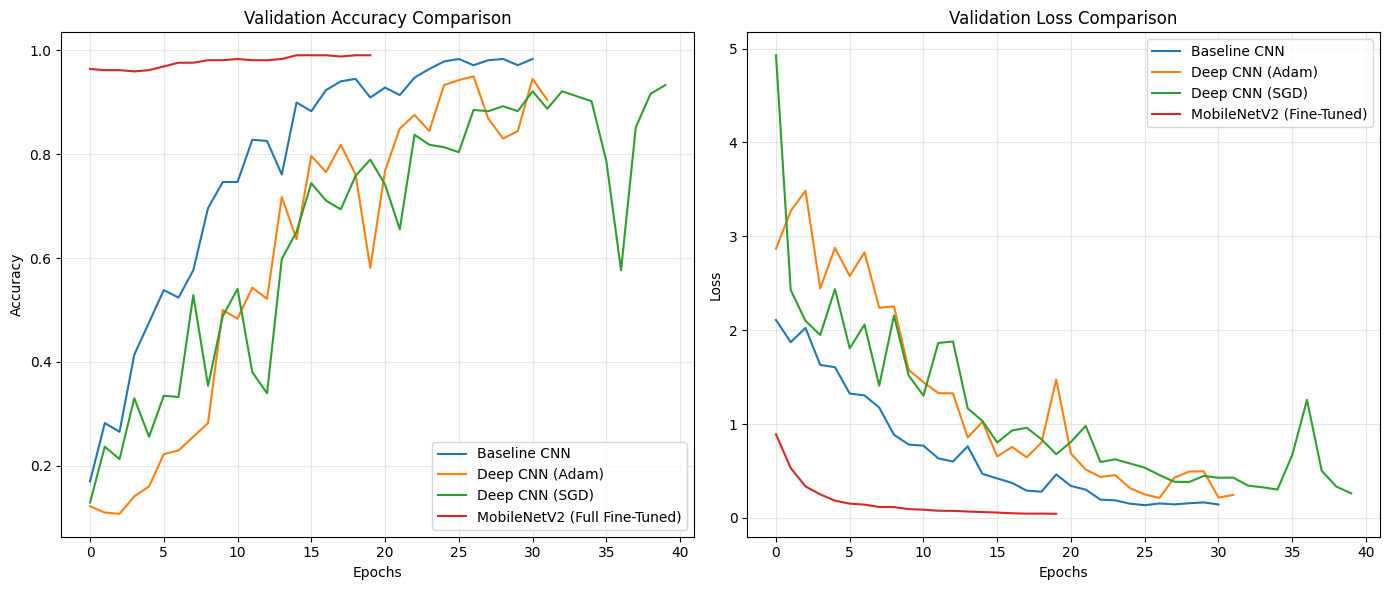

Figure saved: validation_curves_comparison.png


In [83]:
plt.figure(figsize=(14, 6))
# Validation Accuracy
plt.subplot(1, 2, 1)

plt.plot(baseline_log.history['val_accuracy'], label='Baseline CNN')
plt.plot(deep_adam_log.history['val_accuracy'], label='Deep CNN (Adam)')
plt.plot(deep_sgd_log.history['val_accuracy'], label='Deep CNN (SGD)')
plt.plot(full_finetune_log.history['val_accuracy'], label='MobileNetV2 (Full Fine-Tuned)')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

# Validation Loss
plt.subplot(1, 2, 2)

plt.plot(baseline_log.history['val_loss'], label='Baseline CNN')
plt.plot(deep_adam_log.history['val_loss'], label='Deep CNN (Adam)')
plt.plot(deep_sgd_log.history['val_loss'], label='Deep CNN (SGD)')
plt.plot(finetune_log.history['val_loss'], label='MobileNetV2 (Fine-Tuned)')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("validation_curves_comparison.png", dpi=150)
plt.show()

print("Figure saved: validation_curves_comparison.png")

## Final Summary Table (print to notebook)

In [84]:
print("\n" + "=" * 60)
print("          FINAL SUMMARY — ALL MODELS")
print("=" * 60)
print(f"{'Model':<30} {'Test Acc':>12} {'Test Loss':>12}")
print("-" * 60)
summary_rows = [
    ("Baseline CNN",           baseline_acc,  baseline_loss),
    ("Deep CNN (Adam)",        deep_adam_acc, deep_adam_loss),
    ("Deep CNN (SGD)",         deep_sgd_acc,  deep_sgd_loss),
    ("Ablation (no Dropout/BN)", abl_acc,     abl_loss),
    ("MobileNetV2 Fine-Tuned", ft_acc,        ft_loss),
]
for name, acc, loss in summary_rows:
    print(f"{name:<30} {acc:>12.4f} {loss:>12.4f}")
print("=" * 60)
best_model = summary_rows[np.argmax([r[1] for r in summary_rows])][0]
print(f"\nBest performing model: {best_model}")


          FINAL SUMMARY — ALL MODELS
Model                              Test Acc    Test Loss
------------------------------------------------------------
Baseline CNN                         0.9557       0.2899
Deep CNN (Adam)                      0.9375       0.2993
Deep CNN (SGD)                       0.9323       0.3050
Ablation (no Dropout/BN)             0.9583       0.1885
MobileNetV2 Fine-Tuned               0.9844       0.1787

Best performing model: MobileNetV2 Fine-Tuned
